# Predicting Wine Quality using AdaBoost Classifier

### A Boosting-based ML approach to classify high quality wine from physiochemical properties

In [15]:
#Import Required Libraries

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from imblearn.over_sampling import SMOTE
import seaborn as sns
import matplotlib.pyplot as plt

In [16]:
# Load the Dataset(Direct from UCI)

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"
df = pd.read_csv(url, sep = ';') # ';' is the delimiter

In [17]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [18]:
#Create Binary Column
df['target'] = df['quality'].apply(lambda x:1 if x>=7 else 0)

In [19]:
print("Before SMOTE\n",df['target'].value_counts())

Before SMOTE
 target
0    1382
1     217
Name: count, dtype: int64


In [20]:
# Define Feature and target
X = df.drop(['target','quality'], axis =1)
y = df['target']

In [21]:
smote = SMOTE(random_state =42)
X_balanced, y_balanced = smote.fit_resample(X,y)

In [22]:
print("\nAfter SMOTE:\n", y_balanced.value_counts())


After SMOTE:
 target
0    1382
1    1382
Name: count, dtype: int64


In [23]:
#Split into Train ans tests sets
X_train, X_test,y_train,y_test = train_test_split(X_balanced,y_balanced, test_size = 0.2, random_state = 42, stratify = y_balanced)

In [24]:
#Initialize base estimator

base_estimator = DecisionTreeClassifier(max_depth=1)

In [25]:
#Initialize AdaBoost Classifier

ada_model = AdaBoostClassifier(
    estimator=base_estimator,
    n_estimators=50,
    learning_rate=1.0,
    random_state=42
)

In [26]:
ada_model.fit(X_train,y_train)

,estimator,DecisionTreeC...r(max_depth=1)
,n_estimators,50
,learning_rate,1.0
,algorithm,'deprecated'
,random_state,42
,criterion,'gini'
,splitter,'best'
,max_depth,1
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0


In [27]:
y_pred = ada_model.predict(X_test)

In [28]:
#EValuate Performance
print("Classification_report:\n", classification_report(y_test,y_pred))

Classification_report:
               precision    recall  f1-score   support

           0       0.84      0.86      0.85       277
           1       0.85      0.84      0.84       276

    accuracy                           0.85       553
   macro avg       0.85      0.85      0.85       553
weighted avg       0.85      0.85      0.85       553



In [29]:
print("Accuracy Score:", accuracy_score(y_test,y_pred))

Accuracy Score: 0.8462929475587704



 Confusion Matrix:



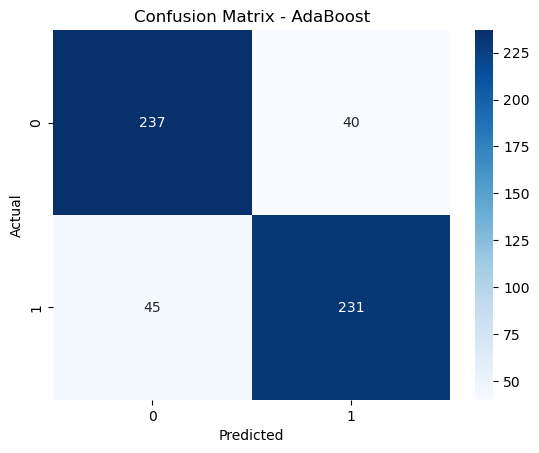

In [30]:
print("\n Confusion Matrix:\n")
cm = confusion_matrix(y_test,y_pred)
sns.heatmap(cm, annot = True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - AdaBoost")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### Observation:

**AdaBoost** imporves performance by focuing more on misclassified examples.